### This notebook demonstrates how to make use of the [SingStat Table Builder - Developer API](https://tablebuilder.singstat.gov.sg/view-api/for-developers) to retrieve the data published by SingStat. We use data on [Graduates From University First Degree Courses By Type Of Course And Sex](https://tablebuilder.singstat.gov.sg/table/TS/M850511) as an example. This notebook is meant to provide an update to a previous [notebook](https://github.com/hxchua/datadoubleconfirm/blob/master/notebooks/SingStat%20API.ipynb) published on my repo related to SingStat API as that API structure has changed. 

In [1]:
import pandas as pd

In [2]:
import json
from urllib.request import Request,urlopen
hdr = {'User-Agent': 'Mozilla/5.0', "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,/;q=0.8"}
url = "https://tablebuilder.singstat.gov.sg/api/table/tabledata/M850511"
request = Request(url,headers=hdr)
data = urlopen(request).read()

In [3]:
json_output = json.loads(data)

In [4]:
json_output

{'Data': {'id': 'M850511',
  'title': 'Graduates From University First Degree Courses By Type Of Course And Sex, Annual',
  'footnote': 'Data prior to 2015 are classified according to the Singapore Standard Educational Classification (SSEC) 2010 while data for 2015 to 2019 and from 2020 are classified according to SSEC 2015 and SSEC 2020 respectively.  Covers full-time and part-time first degree courses.  Data refer to academic year.  With effect from 2011, data included source from MOE.  From 2012, data includes students graduated from Singapore Institute of Technology.  From 2015, data includes students graduated from Singapore University of Technology and Design.  With effect from 2017, there are courses whose main field of study is not elsewhere classifiable.',
  'frequency': 'Annual',
  'datasource': 'MINISTRY OF EDUCATION (FROM 2011), NATIONAL UNIVERSITY OF SINGAPORE, NANYANG TECHNOLOGICAL UNIVERSITY, SINGAPORE MANAGEMENT UNIVERSITY, SINGAPORE INSTITUTE OF TECHNOLOGY (FROM 2012),

In [5]:
json_output.keys()

dict_keys(['Data', 'DataCount', 'StatusCode', 'Message'])

In [7]:
df = pd.json_normalize(json_output['Data']['row'])

In [8]:
df

,seriesNo,rowText,uoM,footnote,columns
0,1,Males,Number,,"[{'key': '1993', 'value': '3565'}, {'key': '19..."
1,1.1,Males: Education,Number,,"[{'key': '1995', 'value': '12'}, {'key': '1996..."
2,1.2,Males: Applied Arts,Number,Includes Industrial Design.,"[{'key': '2003', 'value': '11'}, {'key': '2004..."
3,1.3,Males: Humanities & Social Sciences,Number,,"[{'key': '1993', 'value': '481'}, {'key': '199..."
4,1.4,Males: Mass Communication & Information Science,Number,,"[{'key': '1997', 'value': '28'}, {'key': '1998..."
5,1.5,Males: Accountancy,Number,,"[{'key': '1993', 'value': '295'}, {'key': '199..."
6,1.6,Males: Business & Administration,Number,,"[{'key': '1993', 'value': '282'}, {'key': '199..."
7,1.7,Males: Law,Number,,"[{'key': '1993', 'value': '92'}, {'key': '1994..."
8,1.8,Males: Natural & Mathematical Sciences,Number,,"[{'key': '1993', 'value': '404'}, {'key': '199..."
9,1.9,Males: Medicine,Number,,"[{'key': '1993', 'value': '95'}, {'key': '1994..."


In [9]:
df.explode('columns')

,seriesNo,rowText,uoM,footnote,columns
0,1,Males,Number,,"{'key': '1993', 'value': '3565'}"
0,1,Males,Number,,"{'key': '1994', 'value': '3889'}"
0,1,Males,Number,,"{'key': '1995', 'value': '4003'}"
0,1,Males,Number,,"{'key': '1996', 'value': '4022'}"
0,1,Males,Number,,"{'key': '1997', 'value': '4276'}"
...,...,...,...,...,...
31,2.15,Females: Services,Number,Includes Maritime Studies.,"{'key': '2019', 'value': '91'}"
31,2.15,Females: Services,Number,Includes Maritime Studies.,"{'key': '2020', 'value': '125'}"
31,2.15,Females: Services,Number,Includes Maritime Studies.,"{'key': '2021', 'value': '142'}"
31,2.15,Females: Services,Number,Includes Maritime Studies.,"{'key': '2022', 'value': '95'}"


In [10]:
df = df.explode('columns')

In [11]:
df["columns"].apply(pd.Series)

,key,value
0,1993,3565
0,1994,3889
0,1995,4003
0,1996,4022
0,1997,4276
...,...,...
31,2019,91
31,2020,125
31,2021,142
31,2022,95


In [12]:
df = pd.concat([df, df["columns"].apply(pd.Series)], axis=1)

In [13]:
df = df.drop(['seriesNo','columns','uoM'], axis=1)

In [14]:
df

,rowText,footnote,key,value
0,Males,,1993,3565
0,Males,,1994,3889
0,Males,,1995,4003
0,Males,,1996,4022
0,Males,,1997,4276
...,...,...,...,...
31,Females: Services,Includes Maritime Studies.,2019,91
31,Females: Services,Includes Maritime Studies.,2020,125
31,Females: Services,Includes Maritime Studies.,2021,142
31,Females: Services,Includes Maritime Studies.,2022,95


In [15]:
df.columns = ['Category','footnote','year','count']

In [16]:
df

,Category,footnote,year,count
0,Males,,1993,3565
0,Males,,1994,3889
0,Males,,1995,4003
0,Males,,1996,4022
0,Males,,1997,4276
...,...,...,...,...
31,Females: Services,Includes Maritime Studies.,2019,91
31,Females: Services,Includes Maritime Studies.,2020,125
31,Females: Services,Includes Maritime Studies.,2021,142
31,Females: Services,Includes Maritime Studies.,2022,95


In [17]:
df.dtypes

Category    object
footnote    object
year        object
count       object
dtype: object

In [18]:
df['count'] = pd.to_numeric(df['count'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

In [19]:
import matplotlib.pyplot as plt

In [20]:
df_plot = df[(df['Category']=='Males') | (df['Category']=='Females')].reset_index()

In [21]:
x = df_plot[df_plot['Category']=='Males']['year'].reset_index(drop=True)
y1 = df_plot[df_plot['Category']=='Males']['count'].reset_index(drop=True)
y2 = df_plot[df_plot['Category']=='Females']['count'].reset_index(drop=True)

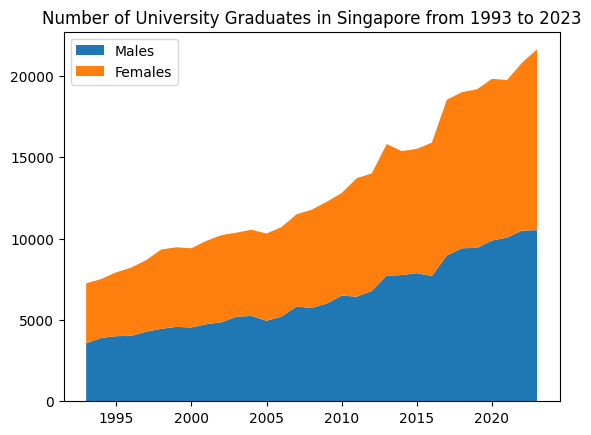

In [24]:
plt.stackplot(x, y1, y2, labels=['Males','Females'])
plt.legend(loc='upper left')
plt.title("Number of University Graduates in Singapore from 1993 to 2023")
plt.show()